In [6]:
# --- Setup ambiente Colab ---
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

!pip install m2cgen -q

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


1. Data Loading & Inspection¶
Here we load the heart.csv dataset. We will check for:

Missing values (Nulls).
Data types matches.
Statistical summary.

In [7]:
# Load the dataset
file_path = '/content/drive/MyDrive/heart.csv'
data = pd.read_csv(file_path)

# Drop columns not available using our sensors
columns_to_drop = ['ChestPainType', 'RestingECG', 'ExerciseAngina', 'Oldpeak', 'ST_Slope']
data = data.drop(columns=columns_to_drop)

# Display first 5 rows
print("--- First 5 rows of the data ---")
display(data.head())

# Check structure
print("\n--- Information & Missing Values ---")
print(data.info())

# Statistical Summary
print("\n--- Statistical Summary ---")
display(data.describe())

--- First 5 rows of the data ---


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,HeartDisease
0,40,M,140,289,0,172,0
1,49,F,160,180,0,156,1
2,37,M,130,283,0,98,0
3,48,F,138,214,0,108,1
4,54,M,150,195,0,122,0



--- Information & Missing Values ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Age           918 non-null    int64 
 1   Sex           918 non-null    object
 2   RestingBP     918 non-null    int64 
 3   Cholesterol   918 non-null    int64 
 4   FastingBS     918 non-null    int64 
 5   MaxHR         918 non-null    int64 
 6   HeartDisease  918 non-null    int64 
dtypes: int64(6), object(1)
memory usage: 50.3+ KB
None

--- Statistical Summary ---


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,1.000000


2. Exploratory Data Analysis (EDA)
Before modeling, we must understand the "story" of the data. We will visualize:

Target Balance: Is the dataset balanced?
Numerical Distributions: How Age and MaxHR correlate with disease.
Categorical Analysis: Chest Pain types and their risk levels.

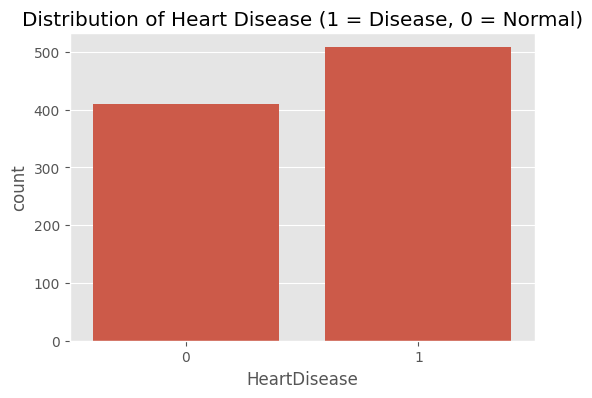

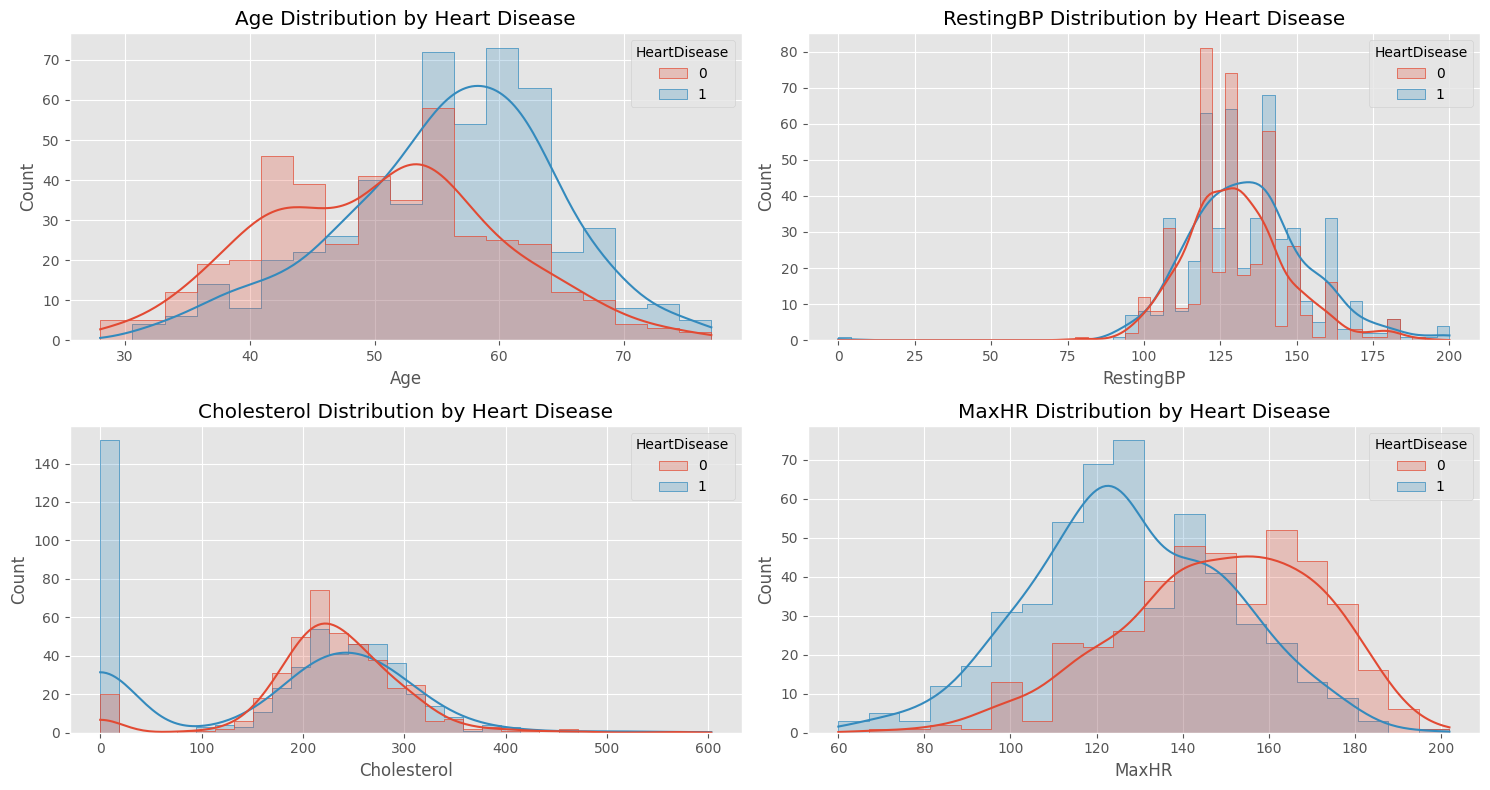

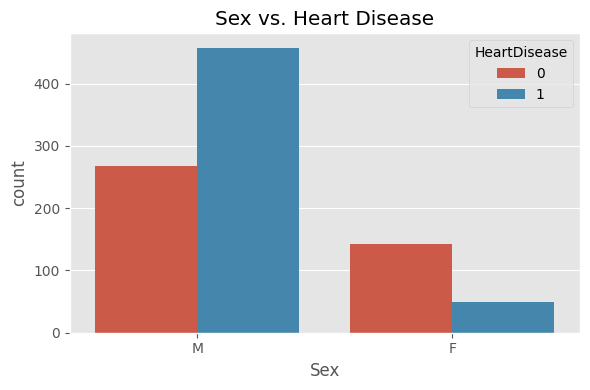

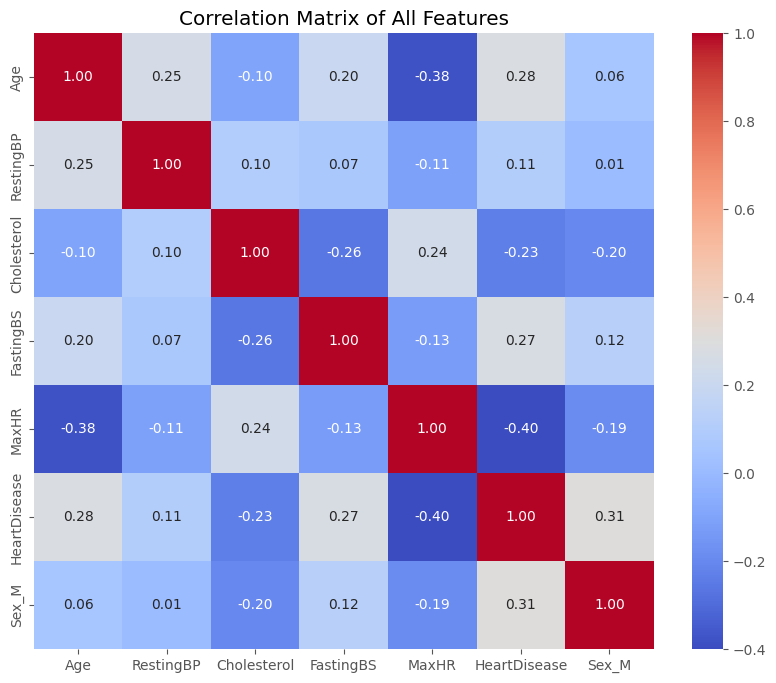

In [8]:
# --- 3.1. Target Variable Distribution ---
plt.figure(figsize=(6, 4))
sns.countplot(x='HeartDisease', data=data)
plt.title('Distribution of Heart Disease (1 = Disease, 0 = Normal)')
plt.show()

# --- 3.2. Numeric Features Distribution ---
numeric_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR']
plt.figure(figsize=(15, 8))
for i, feature in enumerate(numeric_features):
    plt.subplot(2, 2, i + 1)
    sns.histplot(data=data, x=feature, hue='HeartDisease', kde=True, element="step")
    plt.title(f'{feature} Distribution by Heart Disease')
plt.tight_layout()
plt.show()

# --- 3.3. Categorical Features Distribution ---
plt.figure(figsize=(6, 4))
sns.countplot(data=data, x='Sex', hue='HeartDisease')
plt.title('Sex vs. Heart Disease')
plt.tight_layout()
plt.show()

# --- 3.4. Correlation Matrix Heatmap ---
data_for_heatmap = pd.get_dummies(data, drop_first=True)

plt.figure(figsize=(10, 8))
sns.heatmap(data_for_heatmap.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix of All Features')
plt.show()

3. Data Preprocessing Pipeline
To prepare the data for Machine Learning, we apply:

Encoding: Converting text (e.g., 'Male', 'ASY') to numbers using One-Hot Encoding.
Splitting: 80% for Training, 20% for Testing.

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# --- Preprocessing Pipeline ---

# 1. Explicit Binary Encoding
if 'Sex' in data.columns:
    data['Sex'] = data['Sex'].map({'M': 1, 'F': 0})

# 2. Clean Column Names
data.columns = data.columns.str.strip()

# 3. Feature Separation
X = data.drop('HeartDisease', axis=1)
Y = data['HeartDisease']

# 4. Train-Test Split (CRITICAL STEP)
X_Train, X_Test, Y_Train, Y_Test = train_test_split(X, Y, test_size=0.2, random_state=1)

# --- Verification ---
print("--- Preprocessing Completed Successfully ---")
print(f"Data successfully split into:")
print(f"X_Train shape: {X_Train.shape}")
print(f"X_Test shape:  {X_Test.shape}")
print("-" * 40)

--- Preprocessing Completed Successfully ---
Data successfully split into:
X_Train shape: (734, 6)
X_Test shape:  (184, 6)
----------------------------------------


4. Model Training
Random forest training and export as TinyML

 Training Random Forest... Done! (0.07s)

 --- Analysis Report for Random Forest ---
   > Test Accuracy:        75.00%
   > Cross-Val Score:      73.30% (± 3.27%)
   > Precision:            80.77%
   > Sensitivity (Recall): 76.36% (Ability to detect positive cases)
   > F1 Score:             78.50%


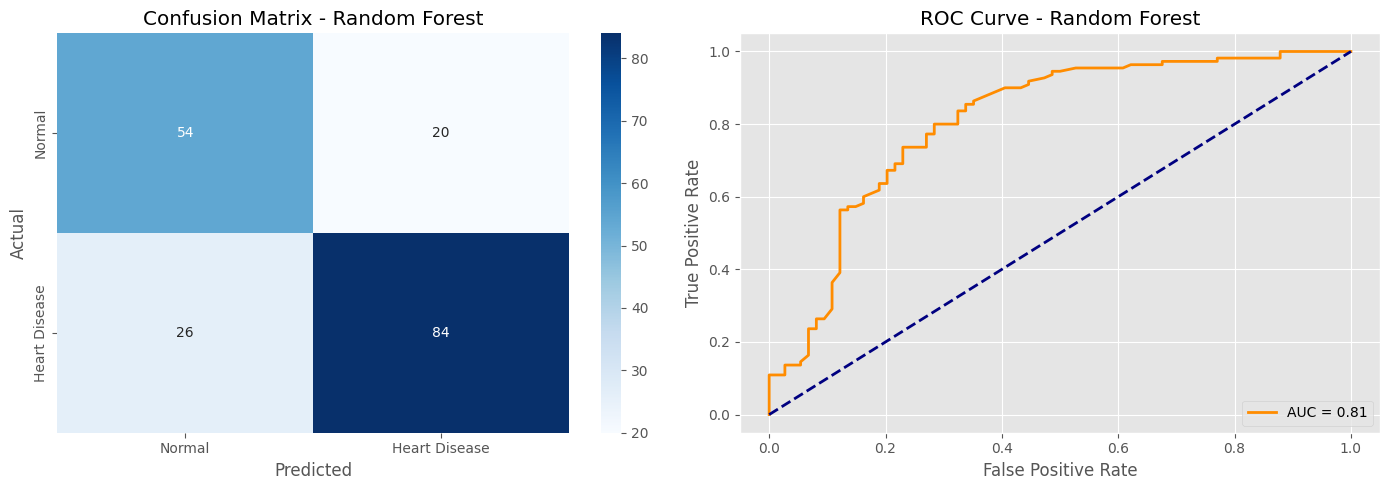

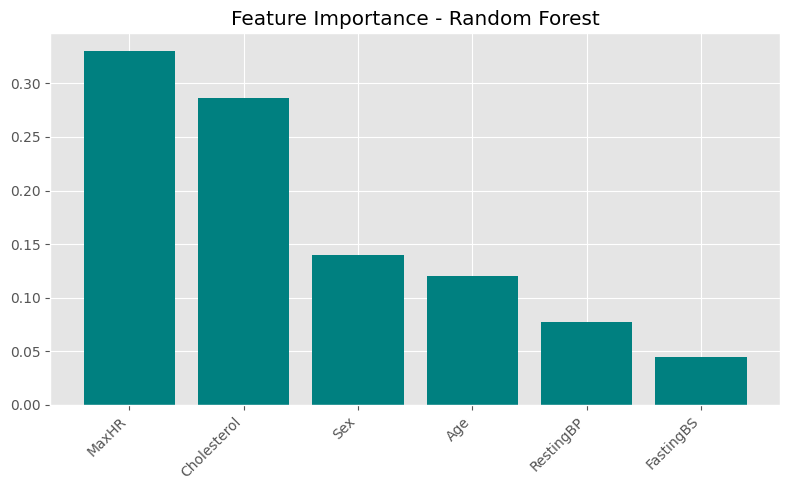


Exporting the C model (TinyML) for Contiki-NG
Model exported: heart_disease_model.h
File size: 19503 characters


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
# Metrics & Evaluation
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             roc_curve, auc, precision_score, recall_score, f1_score)
from sklearn.model_selection import cross_val_score

# Model
from sklearn.ensemble import RandomForestClassifier

# TinyML export
import m2cgen as m2c
from google.colab import files

# --- Configuration & Styling ---
plt.style.use('ggplot')
pd.set_option('display.max_columns', None)

# --- 1. Model Definition ---
# Stessi iperparametri già presenti nella versione precedente del notebook
model = RandomForestClassifier(
    n_estimators=7,
    max_depth=5,
    min_samples_split=40,
    random_state=42,
    n_jobs=-1
)

name = "Random Forest"

# --- 2. Training ---
start_time = time.time()
print(f" Training {name}...", end=" ")
model.fit(X_Train, Y_Train)
training_time = time.time() - start_time
print(f"Done! ({training_time:.2f}s)")

# --- 3. Predictions ---
y_pred = model.predict(X_Test)
y_prob = model.predict_proba(X_Test)[:, 1]

# --- 4. Metrics ---
acc = accuracy_score(Y_Test, y_pred)
prec = precision_score(Y_Test, y_pred)
rec = recall_score(Y_Test, y_pred)
f1 = f1_score(Y_Test, y_pred)

cv_scores = cross_val_score(model, X_Train, Y_Train, cv=5, scoring='accuracy')
cv_mean = cv_scores.mean()
cv_std = cv_scores.std()

print(f"\n --- Analysis Report for {name} ---")
print(f"   > Test Accuracy:        {acc*100:.2f}%")
print(f"   > Cross-Val Score:      {cv_mean*100:.2f}% (± {cv_std*100:.2f}%)")
print(f"   > Precision:            {prec*100:.2f}%")
print(f"   > Sensitivity (Recall): {rec*100:.2f}% (Ability to detect positive cases)")
print(f"   > F1 Score:             {f1*100:.2f}%")

# --- 5. Confusion Matrix & ROC Curve ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(Y_Test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Heart Disease'], yticklabels=['Normal', 'Heart Disease'])
axes[0].set_title(f'Confusion Matrix - {name}')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

fpr, tpr, _ = roc_curve(Y_Test, y_prob)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_title(f'ROC Curve - {name}')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

# --- 6. Feature Importance ---
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(8, 5))
plt.title(f"Feature Importance - {name}")
plt.bar(range(len(importances)), importances[indices], align="center", color='teal')
plt.xticks(range(len(importances)), [X_Train.columns[i] for i in indices], rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- 7. TinyML Export ---
print("\nExporting the C model (TinyML) for Contiki-NG")

# m2cgen directly exports a standard C function (score)
raw_c_code = m2c.export_to_c(model)

# Creation of the header file
header_content = f"""/**
 * Random Forest Model for Heart Disease Detection
 * Automatically generated using m2cgen for Contiki-NG
*/

#ifndef HEART_DISEASE_MODEL_H
#define HEART_DISEASE_MODEL_H

// Standard dependency for generated code
#include <math.h>

// Starting point for generated code
{raw_c_code}
// End of generated code

#endif // HEART_DISEASE_MODEL_H
"""

output_path = 'heart_disease_model.h'
with open(output_path, 'w') as f:
    f.write(header_content)

print(f"Model exported: {output_path}")
print(f"File size: {len(header_content)} characters")

# Download
files.download(output_path)